<a href="https://colab.research.google.com/github/Vardhan466/EcoSync/blob/main/david.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip install qiskit
!pip install qiskit-machine-learning
!pip install qiskit-aer
!pip install psutil
!pip install tabulate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 56.7 MB/s eta 0:00:00


Starting Hybrid QAPINN Training Loop...
Epoch   1/20 | Total Loss: 1.026281 | PDE Loss: 0.001459

Training Complete! Total Time: 473.94 seconds.

--- HYBRID QAPINN METRICS ---
Final PDE Residual Error: 2.776815e-03
Relative L2 Error:        1.000950e+00
Trainable Parameters:     11
Training Time:            473.94 s


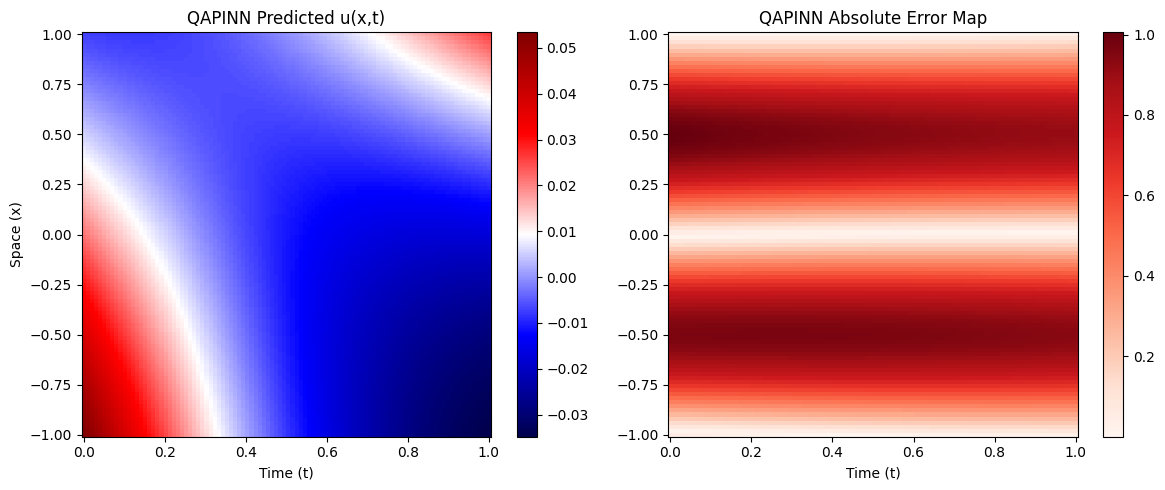

In [7]:
import torch
import torch.nn as nn
import numpy as np
import time
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import SparsePauliOp
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

# --- CONFIGURATION & HYPERPARAMETERS ---
alpha = 0.01          # Thermal diffusivity
N_init = 100          # Initial condition points
N_bound = 100         # Boundary condition points
N_pde = 200          # Reduced PDE points for faster simulator runtime
epochs = 20          # Training epochs for simulation convergence
lr = 0.01

num_qubits = 2
num_layers = 1        # Ansatz circuit depth

# --- STEP 1: QISKIT VQC LAYER CONSTRUCTION ---
inputs = ParameterVector("x", length=num_qubits)
weights = ParameterVector("θ", length=num_qubits * num_layers)

qc = QuantumCircuit(num_qubits)
# Angle encoding layer
for i in range(num_qubits):
    qc.rx(inputs[i], i)
    qc.barrier()

    # Variational layer (Ry + Linear Entanglement)
    weight_idx = 0
    for layer in range(num_layers):
        for i in range(num_qubits):
            qc.ry(weights[weight_idx], i)
            weight_idx += 1
        for i in range(num_qubits - 1):
            qc.cx(i, i + 1)

# Pauli-Z expectation values on all qubits
observables = [SparsePauliOp.from_list([("I" * (num_qubits - 1 - i) + "Z" + "I" * i, 1.0)]) for i in range(num_qubits)]

# FIX #1: input_gradients=True is required whenever the quantum layer is NOT the
# first layer of the network. TorchConnector needs the QNN's Jacobian with respect
# to its OWN inputs in order to keep propagating gradients back into fc1 (and from
# there into X_pde). This defaults to False, which is exactly why the original code
# broke: torch.autograd.grad(u_pred_pde, X_pde, ...) had no path back to X_pde once
# it hit the quantum layer, producing the "not used in the graph" error.
qnn = EstimatorQNN(
    circuit=qc,
    input_params=inputs,
    weight_params=weights,
    observables=observables,
    input_gradients=True,
)
# Wrap the Qiskit QNN into a standard trainable PyTorch Module
quantum_layer = TorchConnector(qnn)

# --- STEP 2: HYBRID QAPINN ARCHITECTURE ---
class QAPINN(nn.Module):
    def __init__(self, q_layer):
        super(QAPINN, self).__init__()
        # Input layer: Maps (x, t) to 'num_qubits' intermediate features matching the qubit count
        self.fc1 = nn.Linear(2, num_qubits) # Changed output dimension to num_qubits (2)
        self.tanh = nn.Tanh()
        # Quantum hidden layer replacement
        self.quantum_layer = q_layer
        # Output layer: Maps 'num_qubits' continuous quantum expectation values to physical solution u
        self.fc2 = nn.Linear(num_qubits, 1) # Changed input dimension to num_qubits (2)

    def forward(self, xt):
        x = self.fc1(xt)
        x = self.tanh(x)
        x = self.quantum_layer(x)  # Continuous output space limited to [-1, 1] per qubit
        x = self.fc2(x)
        return x

model = QAPINN(quantum_layer)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# --- STEP 3: COLLOCATION SAMPLING (Same domain as Phase 2) ---
x_init = np.random.uniform(-1, 1, (N_init, 1))
t_init = np.zeros((N_init, 1))
u_init = -np.sin(np.pi * x_init)

t_bound = np.random.uniform(0, 1, (N_bound, 1))
x_bound = np.vstack([-np.ones((N_bound // 2, 1)), np.ones((N_bound // 2, 1))])
t_bound = np.vstack([t_bound[:N_bound//2], t_bound[N_bound//2:]])
u_bound = np.zeros((N_bound, 1))

x_pde = np.random.uniform(-1, 1, (N_pde, 1))
t_pde = np.random.uniform(0, 1, (N_pde, 1))

X_init = torch.tensor(np.hstack([x_init, t_init]), dtype=torch.float32)
U_init = torch.tensor(u_init, dtype=torch.float32)
X_bound = torch.tensor(np.hstack([x_bound, t_bound]), dtype=torch.float32)
U_bound = torch.tensor(u_bound, dtype=torch.float32)
X_pde = torch.tensor(np.hstack([x_pde, t_pde]), dtype=torch.float32, requires_grad=True)

# Step size for the central finite-difference approximation of u_xx (see FIX #2 below)
FD_H = 1e-2

# --- STEP 4: PHYSICS-INFORMED TRAINING ---
print("Starting Hybrid QAPINN Training Loop...")
start_time = time.time()

for epoch in range(1, epochs + 1):
    optimizer.zero_grad()

    # Boundary constraints evaluation
    u_pred_init = model(X_init)
    loss_init = torch.mean((u_pred_init - U_init) ** 2)

    u_pred_bound = model(X_bound)
    loss_bound = torch.mean((u_pred_bound - U_bound) ** 2)

    # Physics loss tracking (PDE auto-diff)
    u_pred_pde = model(X_pde)

    # u_t: a single first-order derivative. Works fine through the quantum layer now
    # that input_gradients=True is set above.
    grad_xt = torch.autograd.grad(u_pred_pde, X_pde, grad_outputs=torch.ones_like(u_pred_pde),
                                 create_graph=True, retain_graph=True)[0]
    u_t = grad_xt[:, 1:2]

    # FIX #2 - u_xx: TorchConnector computes the quantum layer's Jacobian via the
    # parameter-shift rule using raw numpy, outside PyTorch's autograd graph. That
    # value is fine as the target of one backward pass, but there's nothing for
    # autograd to differentiate a second time - torch.autograd.grad(u_x, X_pde, ...)
    # would hit the same "not used in the graph" failure. A central finite difference
    # in x sidesteps this entirely: it only needs three ordinary forward passes, and
    # those DO backprop correctly into every trainable weight (fc1, quantum θ, fc2),
    # since weight-gradients (unlike input-gradients) are TorchConnector's core,
    # fully-supported use case.
    X_pde_plus = X_pde.detach().clone()
    X_pde_plus[:, 0:1] += FD_H
    X_pde_minus = X_pde.detach().clone()
    X_pde_minus[:, 0:1] -= FD_H

    u_plus = model(X_pde_plus)
    u_minus = model(X_pde_minus)
    u_xx = (u_plus - 2 * u_pred_pde + u_minus) / (FD_H ** 2)

    pde_residual = u_t - alpha * u_xx
    loss_pde = torch.mean(pde_residual ** 2)

    total_loss = loss_init + loss_bound + loss_pde
    total_loss.backward()
    optimizer.step()

    if epoch % 100 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{epochs} | Total Loss: {total_loss.item():.6f} | PDE Loss: {loss_pde.item():.6f}")

training_time = time.time() - start_time
print(f"\nTraining Complete! Total Time: {training_time:.2f} seconds.")

# --- STEP 5: EVALUATION & METRIC CALCULATION ---
x_test = np.linspace(-1, 1, 100)
t_test = np.linspace(0, 1, 100)
X, T = np.meshgrid(x_test, t_test)
XT_test = torch.tensor(np.hstack([X.flatten()[:, None], T.flatten()[:, None]]), dtype=torch.float32)

with torch.no_grad():
    u_pred = model(XT_test).numpy().reshape(X.shape)

    u_exact = -np.exp(-alpha * (np.pi**2) * T) * np.sin(np.pi * X)

    pde_residual_final = loss_pde.item()
    relative_l2_error = np.linalg.norm(u_exact - u_pred) / np.linalg.norm(u_exact)
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print("\n--- HYBRID QAPINN METRICS ---")
    print(f"Final PDE Residual Error: {pde_residual_final:.6e}")
    print(f"Relative L2 Error:        {relative_l2_error:.6e}")
    print(f"Trainable Parameters:     {trainable_params}")
    print(f"Training Time:            {training_time:.2f} s")

    # --- STEP 6: VISUALIZATION ---
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    im0 = ax[0].pcolormesh(T, X, u_pred, cmap='seismic', shading='auto')
    ax[0].set_title("QAPINN Predicted u(x,t)")
    ax[0].set_xlabel("Time (t)")
    ax[0].set_ylabel("Space (x)")
    fig.colorbar(im0, ax=ax[0])

    im1 = ax[1].pcolormesh(T, X, np.abs(u_exact - u_pred), cmap='Reds', shading='auto')
    ax[1].set_title("QAPINN Absolute Error Map")
    ax[1].set_xlabel("Time (t)")
    fig.colorbar(im1, ax=ax[1])
    plt.tight_layout()
    plt.show()

Starting Classical PINN Training...
Epoch    1/20 | Total Loss: 0.582059 | PDE Loss: 0.003337

Training Complete! Total Time: 0.10 seconds.

--- BASELINE METRICS ---
Final PDE Residual Error: 1.383501e-03
Relative L2 Error:        8.716138e-01
Trainable Parameters:     8577
Training Time:            0.10 s


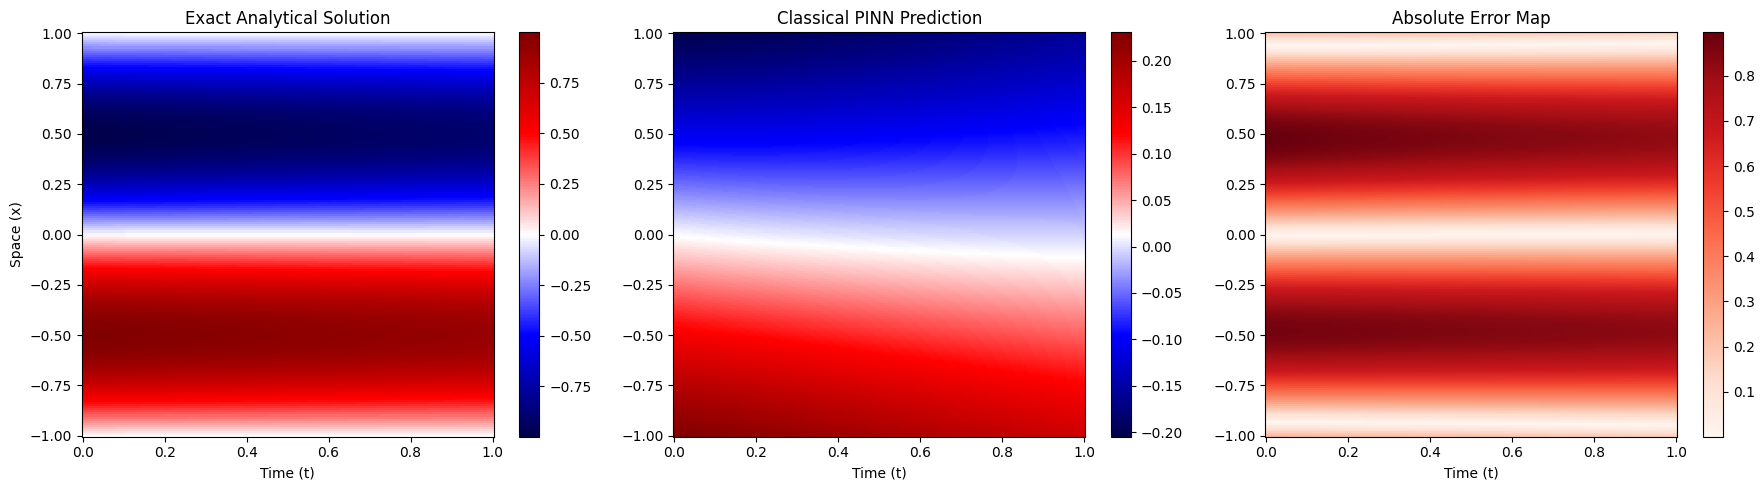

In [10]:
import torch
import torch.nn as nn
import numpy as np
import time
import matplotlib.pyplot as plt

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# --- CONFIGURATION & HYPERPARAMETERS ---
alpha = 0.01          # Thermal diffusivity
N_init = 100          # Number of initial condition points
N_bound = 100         # Number of boundary condition points
N_pde = 200         # Number of interior PDE residual points
epochs = 20
lr = 0.001

# --- STEP 1: DATA GENERATION & SAMPLING ---
# Initial Conditions: t = 0, x ∈ [-1, 1]
x_init = np.random.uniform(-1, 1, (N_init, 1))
t_init = np.zeros((N_init, 1))
u_init = -np.sin(np.pi * x_init)

# Boundary Conditions: x = -1 or x = 1, t ∈ [0, 1]
t_bound = np.random.uniform(0, 1, (N_bound, 1))
x_bound_left = -np.ones((N_bound // 2, 1))
x_bound_right = np.ones((N_bound // 2, 1))
x_bound = np.vstack([x_bound_left, x_bound_right])
t_bound = np.vstack([t_bound[:N_bound//2], t_bound[N_bound//2:]])
u_bound = np.zeros((N_bound, 1))

# Collocation Points for PDE Residual: x ∈ [-1, 1], t ∈ [0, 1]
x_pde = np.random.uniform(-1, 1, (N_pde, 1))
t_pde = np.random.uniform(0, 1, (N_pde, 1))

# Convert to PyTorch Tensors (Enable gradients for PDE points)
X_init = torch.tensor(np.hstack([x_init, t_init]), dtype=torch.float32)
U_init = torch.tensor(u_init, dtype=torch.float32)

X_bound = torch.tensor(np.hstack([x_bound, t_bound]), dtype=torch.float32)
U_bound = torch.tensor(u_bound, dtype=torch.float32)

X_pde = torch.tensor(np.hstack([x_pde, t_pde]), dtype=torch.float32, requires_grad=True)

# --- STEP 2: CLASSICAL PINN ARCHITECTURE ---
class ClassicalPINN(nn.Module):
    def __init__(self):
        super(ClassicalPINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, xt):
        return self.net(xt)

model = ClassicalPINN()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# --- STEP 3: TRAINING LOOP WITH PHYSICS LOSS ---
print("Starting Classical PINN Training...")
start_time = time.time()

for epoch in range(1, epochs + 1):
    optimizer.zero_grad()

    # 1. Data-Driven Loss (Initial + Boundary Conditions)
    u_pred_init = model(X_init)
    loss_init = torch.mean((u_pred_init - U_init) ** 2)

    u_pred_bound = model(X_bound)
    loss_bound = torch.mean((u_pred_bound - U_bound) ** 2)

    # 2. Physics-Informed Loss (PDE Residual)
    u_pred_pde = model(X_pde)

    # Separate x and t out of the input matrix to calculate explicit partials
    x = X_pde[:, 0:1]
    t = X_pde[:, 1:2]

    # Compute du/dx and du/dt
    u_x = torch.autograd.grad(u_pred_pde, X_pde, grad_outputs=torch.ones_like(u_pred_pde),
                              create_graph=True, retain_graph=True)[0][:, 0:1]
    u_t = torch.autograd.grad(u_pred_pde, X_pde, grad_outputs=torch.ones_like(u_pred_pde),
                              create_graph=True, retain_graph=True)[0][:, 1:2]

    # Compute d^2u/dx^2
    u_xx = torch.autograd.grad(u_x, X_pde, grad_outputs=torch.ones_like(u_x),
                               create_graph=True, retain_graph=True)[0][:, 0:1]

    # Heat Equation Residual: u_t - alpha * u_xx = 0
    pde_residual = u_t - alpha * u_xx
    loss_pde = torch.mean(pde_residual ** 2)

    # Total Composite Loss
    total_loss = loss_init + loss_bound + loss_pde

    total_loss.backward()
    optimizer.step()

    if epoch % 500 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d}/{epochs} | Total Loss: {total_loss.item():.6f} | PDE Loss: {loss_pde.item():.6f}")

training_time = time.time() - start_time
print(f"\nTraining Complete! Total Time: {training_time:.2f} seconds.")

# --- STEP 4: METRICS EVALUATION ---
# Generate a uniform grid for testing evaluation
x_test = np.linspace(-1, 1, 200)
t_test = np.linspace(0, 1, 200)
X, T = np.meshgrid(x_test, t_test)
X_flat = X.flatten()[:, None]
T_flat = T.flatten()[:, None]
XT_test = torch.tensor(np.hstack([X_flat, T_flat]), dtype=torch.float32)

# Model Prediction vs Exact Solution
with torch.no_grad():
    u_pred = model(XT_test).numpy().reshape(X.shape)

u_exact = -np.exp(-alpha * (np.pi**2) * T) * np.sin(np.pi * X)

# Calculate Errors
pde_residual_final = loss_pde.item()
relative_l2_error = np.linalg.norm(u_exact - u_pred) / np.linalg.norm(u_exact)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\n--- BASELINE METRICS ---")
print(f"Final PDE Residual Error: {pde_residual_final:.6e}")
print(f"Relative L2 Error:        {relative_l2_error:.6e}")
print(f"Trainable Parameters:     {trainable_params}")
print(f"Training Time:            {training_time:.2f} s")

# --- STEP 5: VISUALIZATION ---
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Plot Exact Solution
im0 = ax[0].pcolormesh(T, X, u_exact, cmap='seismic', shading='auto')
ax[0].set_title("Exact Analytical Solution")
ax[0].set_xlabel("Time (t)")
ax[0].set_ylabel("Space (x)")
fig.colorbar(im0, ax=ax[0])

# Plot PINN Prediction
im1 = ax[1].pcolormesh(T, X, u_pred, cmap='seismic', shading='auto')
ax[1].set_title("Classical PINN Prediction")
ax[1].set_xlabel("Time (t)")
fig.colorbar(im1, ax=ax[1])

# Plot Absolute Error Map
im2 = ax[2].pcolormesh(T, X, np.abs(u_exact - u_pred), cmap='Reds', shading='auto')
ax[2].set_title("Absolute Error Map")
ax[2].set_xlabel("Time (t)")
fig.colorbar(im2, ax=ax[2])

plt.tight_layout()
plt.show()

In [11]:
!pip install qiskit qiskit-machine-learning
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import SparsePauliOp
from qiskit_machine_learning.neural_networks import EstimatorQNN

# --- CONFIGURATION ---
num_qubits = 4
num_features = 4  # Number of classical inputs fed into the quantum layer
num_layers = 2    # Circuit depth (repetitions of the ansatz block)

# 1. DEFINE SYMBOLIC PARAMETERS
# 'inputs' represent the classical variables changing per data point (x, t, or hidden features)
inputs = ParameterVector("x", length=num_features)
# 'weights' represent the trainable internal quantum parameters (θ) updated by the optimizer
weights = ParameterVector("θ", length=num_qubits * num_layers)

# 2. BUILD THE VARIATIONAL QUANTUM CIRCUIT (VQC)
qc = QuantumCircuit(num_qubits)

# --- STAGE A: ANGLE ENCODING (FEATURE MAP) ---
# Map classical inputs directly to single-qubit Rx rotations
for i in range(min(num_features, num_qubits)):
    qc.rx(inputs[i], i)

qc.barrier()  # Visual separator between encoding and processing

# --- STAGE B: VARIATIONAL ANSATZ LAYER WITH CNOT ENTANGLEMENT ---
weight_idx = 0
for layer in range(num_layers):
    # Parameterized Rotations
    for i in range(num_qubits):
        qc.ry(weights[weight_idx], i)
        weight_idx += 1

    # Linear Entanglement (CNOT Chain)
    for i in range(num_qubits - 1):
        qc.cx(i, i + 1)

    qc.barrier()

# Draw the parameterized circuit visualization
print("--- CONSTRUCTED VARIATIONAL QUANTUM CIRCUIT ANATZ ---")
print(qc.draw(output="text"))

# --- STAGE C: MEASUREMENT OPERATORS ---
# We track the expectation value <Z> for each individual qubit independently.
# This yields a continuous real-valued vector output matching the qubit count.
observables = [SparsePauliOp.from_list([("I" * (num_qubits - 1 - i) + "Z" + "I" * i, 1.0)]) for i in range(num_qubits)]

# 3. INTERFACE WITH QISKIT MACHINE LEARNING NN PRIMITIVE
# EstimatorQNN handles the calculations of forward passes and exact gradients automatically.
qnn = EstimatorQNN(
    circuit=qc,
    input_params=inputs,
    weight_params=weights,
    observables=observables
)

# --- 4. VERIFICATION: FORWARD PASS SIMULATION ---
# Generate dummy classical inputs and random internal initial weights
sample_input = np.random.uniform(-np.pi, np.pi, num_features)
sample_weights = np.random.uniform(-np.pi, np.pi, len(weights))

# Perform a forward pass evaluation through the simulator
output_expectation = qnn.forward(input_data=sample_input, weights=sample_weights)

print("\n--- FORWARD PASS CHECKPOINT ---")
print(f"Classical Inputs Evaluated:    {sample_input}")
print(f"Resulting VQC Output Vector:  {output_expectation[0]}")

--- CONSTRUCTED VARIATIONAL QUANTUM CIRCUIT ANATZ ---
     ┌──────────┐ ░ ┌──────────┐                ░ ┌──────────┐               »
q_0: ┤ Rx(x[0]) ├─░─┤ Ry(θ[0]) ├──■─────────────░─┤ Ry(θ[4]) ├──■────────────»
     ├──────────┤ ░ ├──────────┤┌─┴─┐           ░ ├──────────┤┌─┴─┐          »
q_1: ┤ Rx(x[1]) ├─░─┤ Ry(θ[1]) ├┤ X ├──■────────░─┤ Ry(θ[5]) ├┤ X ├──■───────»
     ├──────────┤ ░ ├──────────┤└───┘┌─┴─┐      ░ ├──────────┤└───┘┌─┴─┐     »
q_2: ┤ Rx(x[2]) ├─░─┤ Ry(θ[2]) ├─────┤ X ├──■───░─┤ Ry(θ[6]) ├─────┤ X ├──■──»
     ├──────────┤ ░ ├──────────┤     └───┘┌─┴─┐ ░ ├──────────┤     └───┘┌─┴─┐»
q_3: ┤ Rx(x[3]) ├─░─┤ Ry(θ[3]) ├──────────┤ X ├─░─┤ Ry(θ[7]) ├──────────┤ X ├»
     └──────────┘ ░ └──────────┘          └───┘ ░ └──────────┘          └───┘»
«      ░ 
«q_0: ─░─
«      ░ 
«q_1: ─░─
«      ░ 
«q_2: ─░─
«      ░ 
«q_3: ─░─
«      ░ 

--- FORWARD PASS CHECKPOINT ---
Classical Inputs Evaluated:    [-2.08014235 -1.39115793 -2.02940298 -2.5842582 ]
Resulting VQC Output Vector:  [

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import time
import os
import psutil  # For system memory profiling
import pandas as pd
from tabulate import tabulate

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import SparsePauliOp
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector

# --- SYSTEM UTILITY FOR MEMORY PROFILE ---
def get_memory_usage_mb():
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / (1024 ** 2)

# --- GLOBAL PHYSICS CONFIGURATION ---
alpha = 0.01
N_init, N_bound, N_pde = 80, 80, 200  # Streamlined counts for simulator grid sweep
epochs = 20                           # Low epoch checkpoint to profile early trajectories
lr = 0.01
FD_H = 1e-2                            # Step size for the finite-difference u_xx (see below)

# Synthesize physical coordinate domains
x_init = np.random.uniform(-1, 1, (N_init, 1))
X_init = torch.tensor(np.hstack([x_init, np.zeros_like(x_init)]), dtype=torch.float32)
U_init = torch.tensor(-np.sin(np.pi * x_init), dtype=torch.float32)

t_bound = np.random.uniform(0, 1, (N_bound, 1))
x_bound = np.vstack([-np.ones((N_bound//2, 1)), np.ones((N_bound//2, 1))])
X_bound = torch.tensor(np.hstack([x_bound, np.vstack([t_bound[:N_bound//2], t_bound[N_bound//2:]])]), dtype=torch.float32)
U_bound = torch.tensor(np.zeros((N_bound, 1)), dtype=torch.float32)

X_pde = torch.tensor(np.hstack([np.random.uniform(-1, 1, (N_pde, 1)), np.random.uniform(0, 1, (N_pde, 1))]), dtype=torch.float32, requires_grad=True)

# FIX: precompute the shifted collocation points once, up front. X_pde is fixed
# for the whole script (never resampled per epoch or per config), so there's no
# reason to rebuild these on every one of the 36 * 200 training steps.
X_pde_plus = X_pde.detach().clone()
X_pde_plus[:, 0:1] += FD_H
X_pde_minus = X_pde.detach().clone()
X_pde_minus[:, 0:1] -= FD_H

# Test grid initialization for Relative L2 tracking
x_t, t_t = np.meshgrid(np.linspace(-1, 1, 50), np.linspace(0, 1, 50))
XT_test = torch.tensor(np.hstack([x_t.flatten()[:, None], t_t.flatten()[:, None]]), dtype=torch.float32)
u_exact = -np.exp(-alpha * (np.pi**2) * t_t) * np.sin(np.pi * x_t)

# --- DYNAMIC VQC LAYER CONSTRUCTOR ---
def build_quantum_layer(num_qubits, depth, entanglement, encoding_method):
    inputs = ParameterVector("x", length=num_qubits)
    weights = ParameterVector("θ", length=num_qubits * depth)
    qc = QuantumCircuit(num_qubits)

    # 1. Select Encoding Method
    for i in range(num_qubits):
        if encoding_method == "Rx":
            qc.rx(inputs[i], i)
        elif encoding_method == "Ry":
            qc.ry(inputs[i], i)

    qc.barrier()

    # 2. Add Ansatz Layers with Selective Entanglement Topology
    w_idx = 0
    for d in range(depth):
        for i in range(num_qubits):
            qc.ry(weights[w_idx], i)
            w_idx += 1

        if entanglement == "linear":
            for i in range(num_qubits - 1):
                qc.cx(i, i + 1)
        elif entanglement == "full":
            for i in range(num_qubits):
                for j in range(i + 1, num_qubits):
                    qc.cx(i, j)
        qc.barrier()

    observables = [SparsePauliOp.from_list([("I"*(num_qubits-1-i) + "Z" + "I"*i, 1.0)]) for i in range(num_qubits)]
    # FIX: input_gradients=True is required whenever the quantum layer isn't the
    # first layer of the network (here it follows fc1 + tanh). Without it,
    # TorchConnector never returns a gradient w.r.t. its own input, so
    # torch.autograd.grad(u_pde, X_pde, ...) has no path back to X_pde and raises
    # "One of the differentiated Tensors appears to not have been used in the
    # graph" -- which is what was silently failing all 36 configs before.
    qnn = EstimatorQNN(
        circuit=qc,
        input_params=inputs,
        weight_params=weights,
        observables=observables,
        input_gradients=True,
    )
    return TorchConnector(qnn)

# --- DYNAMIC QAPINN MODEL WRAPPER ---
class DynamicQAPINN(nn.Module):
    def __init__(self, num_qubits, q_layer):
        super(DynamicQAPINN, self).__init__()
        self.fc1 = nn.Linear(2, num_qubits)
        self.tanh = nn.Tanh()
        self.quantum_layer = q_layer
        self.fc2 = nn.Linear(num_qubits, 1)

    def forward(self, xt):
        return self.fc2(self.quantum_layer(self.tanh(self.fc1(xt))))

# --- HYPERPARAMETER EXPERIMENTAL GRID DEFINITION ---
qubit_options = [2, 4, 6]
depth_options = [1, 2, 3]
entanglement_options = ["linear", "full"]
encoding_options = ["Rx", "Ry"]

results_archive = []

print("🚀 Initiating QAPINN Architecture Experimental Grid Sweep...")

# Start structural loop executions
for n_q in qubit_options:
    for depth in depth_options:
        for ent in entanglement_options:
            for enc in encoding_options:

                # Performance baseline isolation
                torch.manual_seed(42)
                np.random.seed(42)

                mem_start = get_memory_usage_mb()
                time_start = time.time()

                try:
                    # Construct and bind network configurations dynamically
                    q_layer = build_quantum_layer(n_q, depth, ent, enc)
                    model = DynamicQAPINN(n_q, q_layer)
                    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

                    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

                    # Target Execution Loop
                    for epoch in range(epochs):
                        optimizer.zero_grad()
                        loss_init = torch.mean((model(X_init) - U_init)**2)
                        loss_bound = torch.mean((model(X_bound) - U_bound)**2)

                        u_pde = model(X_pde)

                        # u_t: a single first-order derivative. Works fine through the
                        # quantum layer now that input_gradients=True is set above.
                        u_t = torch.autograd.grad(u_pde, X_pde, grad_outputs=torch.ones_like(u_pde),
                                                   create_graph=True, retain_graph=True)[0][:, 1:2]

                        # u_xx: TorchConnector's backward computes the quantum layer's
                        # Jacobian via the parameter-shift rule in plain numpy, detached
                        # from the autograd graph -- there's nothing for a second
                        # differentiation to attach to, so grad(u_x, X_pde) would fail
                        # the same way. A central finite difference in x only needs
                        # ordinary forward passes, which DO backprop correctly into
                        # every trainable weight (fc1, quantum θ, fc2).
                        u_plus = model(X_pde_plus)
                        u_minus = model(X_pde_minus)
                        u_xx = (u_plus - 2 * u_pde + u_minus) / (FD_H ** 2)

                        loss_pde = torch.mean((u_t - alpha * u_xx)**2)
                        (loss_init + loss_bound + loss_pde).backward()
                        optimizer.step()

                    # Metric Aggregation Post Optimization
                    elapsed_time = time.time() - time_start
                    mem_peak = get_memory_usage_mb() - mem_start

                    with torch.no_grad():
                        u_pred = model(XT_test).numpy().reshape(u_exact.shape)
                    rel_l2 = np.linalg.norm(u_exact - u_pred) / np.linalg.norm(u_exact)

                    # Record tracking vector
                    config_result = {
                        "Qubits": n_q, "Depth": depth, "Entangle": ent, "Encoding": enc,
                        "PDE Residual": f"{loss_pde.item():.4e}", "Rel L2": f"{rel_l2:.4e}",
                        "Time (s)": f"{elapsed_time:.2f}", "Params": trainable_params,
                        "Mem (MB)": f"{max(mem_peak, 0.01):.2f}"
                    }
                    results_archive.append(config_result)
                    print(f"✅ Success: Qubits={n_q} | Depth={depth} | Ent={ent} | Enc={enc} ──> L2 Error: {rel_l2:.4f}")

                except Exception as error_msg:
                    print(f"❌ Execution Failure on Target Configuration: Qubits={n_q}, Depth={depth}. Msg: {error_msg}")

# --- 2. REPORT GENERATION ---
df = pd.DataFrame(results_archive)
df.to_csv("qapinn_experimental_matrix.csv", index=False)

print("\n\n=== FINAL EXPERIMENTAL RESULTS GRID MATRIX ===")
print(tabulate(df, headers="keys", tablefmt="grid", showindex=False))

🚀 Initiating QAPINN Architecture Experimental Grid Sweep...


✅ Success: Qubits=2 | Depth=1 | Ent=linear | Enc=Rx ──> L2 Error: 1.1316


✅ Success: Qubits=2 | Depth=1 | Ent=linear | Enc=Ry ──> L2 Error: 1.1249


✅ Success: Qubits=2 | Depth=1 | Ent=full | Enc=Rx ──> L2 Error: 1.1316


✅ Success: Qubits=2 | Depth=1 | Ent=full | Enc=Ry ──> L2 Error: 1.1249


✅ Success: Qubits=2 | Depth=2 | Ent=linear | Enc=Rx ──> L2 Error: 1.2377


✅ Success: Qubits=2 | Depth=2 | Ent=linear | Enc=Ry ──> L2 Error: 1.0633


✅ Success: Qubits=2 | Depth=2 | Ent=full | Enc=Rx ──> L2 Error: 1.2377
